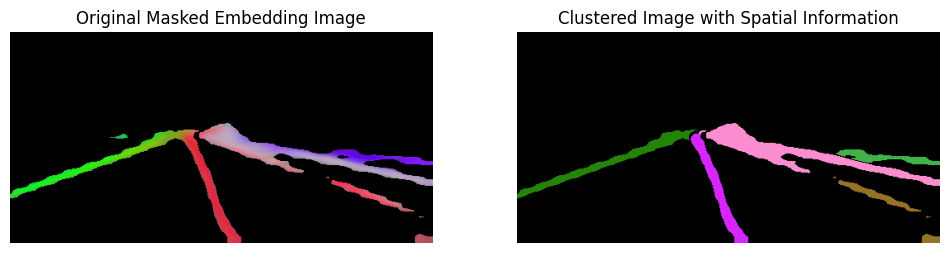

In [1]:
import numpy as np
import cv2
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from skimage import io

# Load the npz files
binary_data = np.load('/content/binary_image.npz')
embedding_data = np.load('/content/embedding_image.npz')

# Extract the arrays
binary_image = binary_data['binary_image']
embedding_image_original = embedding_data['embedding_image']

# Ensure the embedding image has 3 channels
embedding_image = embedding_image_original[:, :, 0:3]

# Create a masked embedding image
masked_embedding_image = np.zeros_like(embedding_image)
mask = binary_image > 0
masked_embedding_image[mask] = embedding_image[mask]

# Extract the height and width of the image
h, w, _ = masked_embedding_image.shape

# Create a mask for non-black pixels (assuming black pixels are [0, 0, 0])
mask = np.any(masked_embedding_image != [0, 0, 0], axis=-1)

# Extract the RGB values and their corresponding coordinates
pixels = masked_embedding_image[mask].reshape(-1, 3)
coords = np.column_stack(np.nonzero(mask))

# Combine RGB values with coordinates
features = np.concatenate([pixels, coords], axis=1)

# Perform DBSCAN clustering
eps = 30  # Epsilon parameter for DBSCAN (this may require tuning)
min_samples = 100  # Minimum samples for a core point in DBSCAN
db = DBSCAN(eps=eps, min_samples=min_samples).fit(features)
labels = db.labels_

# Create an empty image for the clustered result
clustered_img = np.zeros_like(masked_embedding_image)

# Get the unique labels
unique_labels = np.unique(labels)
n_clusters = len(unique_labels) - (1 if -1 in labels else 0)  # Exclude noise if present

# Generate random colors for each cluster
colors = np.random.randint(0, 255, size=(n_clusters, 3))

# Assign cluster colors to the original image based on labels
for label, (x, y) in zip(labels, coords):
    if label != -1:  # Ignore noise
        clustered_img[x, y] = colors[label % n_clusters]

# Plot the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Masked Embedding Image')
plt.imshow(cv2.cvtColor(masked_embedding_image, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Clustered Image with Spatial Information')
plt.imshow(cv2.cvtColor(clustered_img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()


Coordinates for Cluster 0:
[[111 261]
 [111 262]
 [111 263]
 ...
 [186 509]
 [186 510]
 [186 511]]


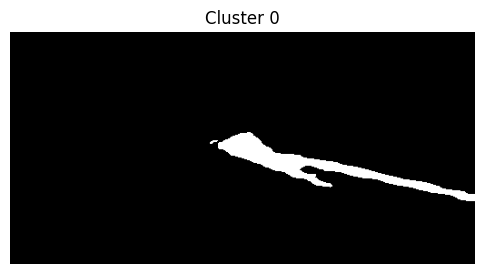

Coordinates for Cluster 1:
[[119 210]
 [119 211]
 [119 212]
 ...
 [201   0]
 [201   1]
 [201   2]]


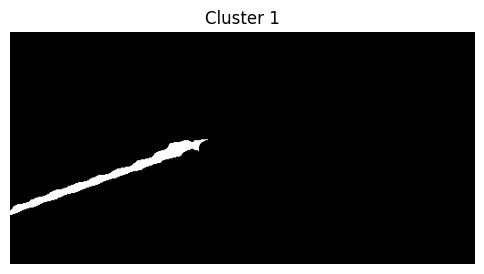

Coordinates for Cluster 2:
[[124 214]
 [124 215]
 [124 216]
 ...
 [255 277]
 [255 278]
 [255 279]]


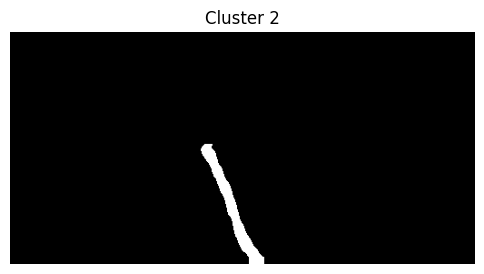

Coordinates for Cluster 3:
[[143 396]
 [143 397]
 [143 398]
 ...
 [161 509]
 [161 510]
 [161 511]]


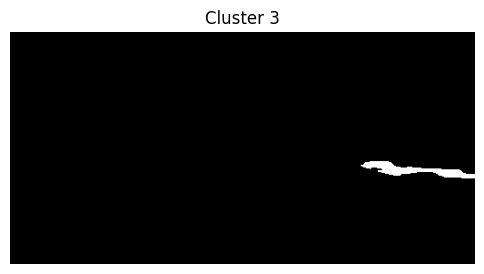

Coordinates for Cluster 4:
[[176 382]
 [176 383]
 [176 384]
 ...
 [255 509]
 [255 510]
 [255 511]]


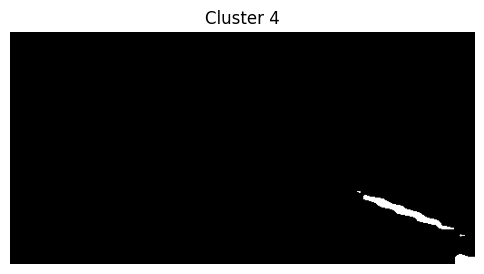

In [3]:

result=[]
cluster_imgs=[]
# Plot each cluster separately and print coordinates
for cluster_idx in unique_labels:
    if cluster_idx == -1:  # Ignore noise
        continue
    cluster_img = np.zeros_like(masked_embedding_image)
    cluster_coords = []

    for label, (x, y) in zip(labels, coords):
        if label == cluster_idx:
            #cluster_img[x, y] = masked_embedding_image[x, y]
            cluster_img[x, y]=255
            cluster_coords.append((x, y))
    cluster_imgs.append(cluster_img)
    # Convert the list of coordinates to a numpy array for easier manipulation
    cluster_coords = np.array(cluster_coords)

    result.append(cluster_coords)

    # Print coordinates for the current cluster
    print(f'Coordinates for Cluster {cluster_idx}:')
    print(cluster_coords)

    # Plot the cluster image
    plt.figure(figsize=(6, 6))
    plt.title(f'Cluster {cluster_idx}')
    plt.imshow(cv2.cvtColor(cluster_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


5


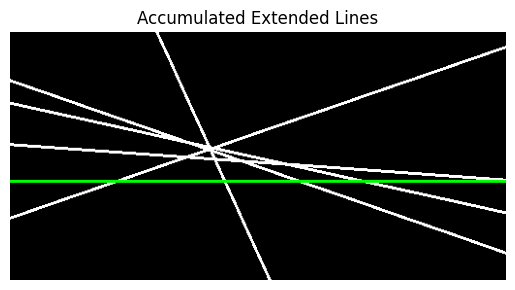

{'Cluster_0': 358, 'Cluster_1': 106, 'Cluster_2': 220, 'Cluster_3': 509, 'Cluster_4': 295}
{'Cluster_0': 3, 'Cluster_1': 0, 'Cluster_2': 1, 'Cluster_3': 4, 'Cluster_4': 2}


In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to process an image and return the blank image with the extended line
def process_image(image):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply binary thresholding
    _, binary_image = cv2.threshold(gray_image, 1, 255, cv2.THRESH_BINARY)

    # Detect edges using Canny
    edges = cv2.Canny(binary_image, 50, 150, apertureSize=3)

    # Detect lines using the probabilistic Hough transform
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=15, minLineLength=50, maxLineGap=10)

    # Create a blank image to draw the extended line
    blank_image = np.zeros_like(image)

    # If lines are detected, process the first detected line
    if lines is not None and len(lines) > 0:
        #print(f"Number of lines detected: {len(lines)}")
        # Take the first detected line
        x1, y1, x2, y2 = lines[0][0]

        # Extend the line
        extension_length = 500  # Length to extend on each side
        angle = np.arctan2(y2 - y1, x2 - x1)
        x1_ext = int(x1 - extension_length * np.cos(angle))
        y1_ext = int(y1 - extension_length * np.sin(angle))
        x2_ext = int(x2 + extension_length * np.cos(angle))
        y2_ext = int(y2 + extension_length * np.sin(angle))

        # Draw the extended line on the blank image
        cv2.line(blank_image, (x1_ext, y1_ext), (x2_ext, y2_ext), (255, 255, 255), 2)

    return blank_image, lines[0][0] if lines is not None and len(lines) > 0 else None

def max_count(image):
    h, w = image.shape[0], image.shape[1]
    max_y = 0
    max_count = 0
    for i in range(h):
        count = 0
        for j in range(w-1):
            if image[h-1-i][j][0] == 0 and image[h-1-i][j+1][0] != 0:
                count += 1
        if max_count < count:
            max_count = count
            max_y = h-1-i
    print(max_count)
    return max_y

def find_intersection_y(line_image, green_y):
    h, w = line_image.shape[:2]
    for x in range(w):
        if line_image[green_y, x][0] != 0:
            return x
    return None

# Assuming cluster_imgs is a list of images
# Initialize a blank image to accumulate results
accumulated_image = np.zeros_like(cluster_imgs[0])

# Process images from cluster_imgs[0] to cluster_imgs[4]
for i in range(5):
    processed_image, _ = process_image(cluster_imgs[i])
    accumulated_image = cv2.add(accumulated_image, processed_image)

rr = max_count(accumulated_image)
cv2.line(accumulated_image, (0, rr), (accumulated_image.shape[1], rr), (0, 255, 0), 2)

intersection_dict = {}

# Find the intersection points for each cluster image
for i in range(5):
    processed_image, _ = process_image(cluster_imgs[i])
    intersection_x = find_intersection_y(processed_image, rr)
    intersection_dict[f'Cluster_{i}'] = intersection_x

# Display the result
plt.imshow(cv2.cvtColor(accumulated_image, cv2.COLOR_BGR2RGB))
plt.title('Accumulated Extended Lines')
plt.axis('off')
plt.show()

# Sort the values and create rankings
sorted_values = sorted(intersection_dict.values())

# Create a dictionary to map original values to their ranks
value_to_rank = {value: rank for rank, value in enumerate(sorted_values) if value is not None}

# Replace the values in the original dictionary with their ranks
ranked_dict = {key: value_to_rank[value] for key, value in intersection_dict.items() if value is not None}

print(intersection_dict)
print(ranked_dict)


Distance from point (245, 143) to the line in image 0: 14.55


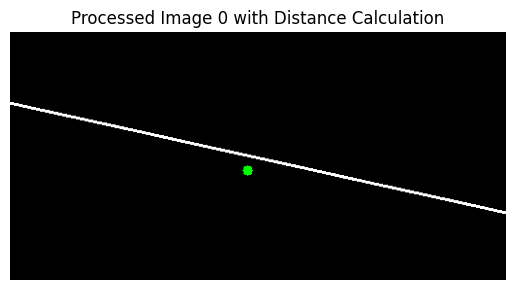

Distance from point (245, 143) to the line in image 1: 33.71


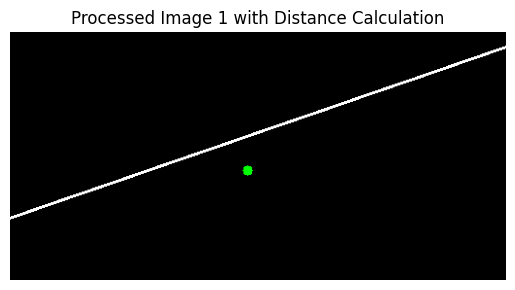

Distance from point (245, 143) to the line in image 2: 25.62


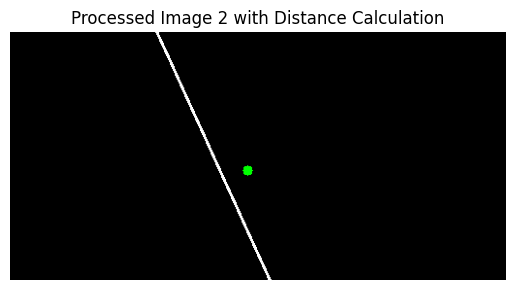

Distance from point (245, 143) to the line in image 3: 8.52


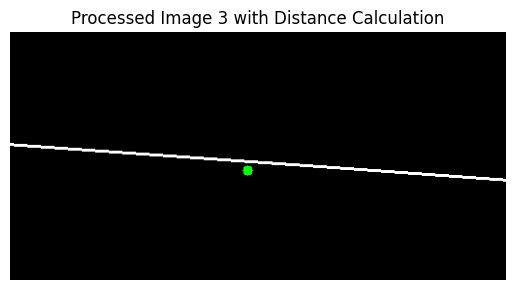

Distance from point (245, 143) to the line in image 4: 6.73


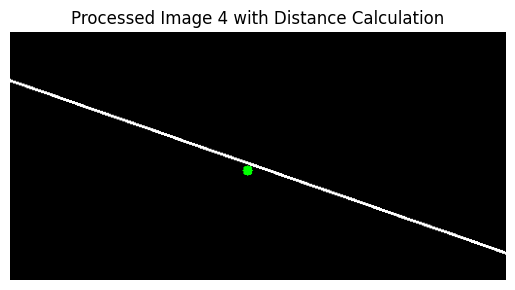

4
{'Cluster_0': 358, 'Cluster_1': 106, 'Cluster_2': 220, 'Cluster_3': 509, 'Cluster_4': 295}
left


In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to process an image and return the blank image with the extended line
def process_image(image):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply binary thresholding
    _, binary_image = cv2.threshold(gray_image, 1, 255, cv2.THRESH_BINARY)

    # Detect edges using Canny
    edges = cv2.Canny(binary_image, 50, 150, apertureSize=3)

    # Detect lines using the probabilistic Hough transform
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=15, minLineLength=50, maxLineGap=10)

    # Create a blank image to draw the extended line
    blank_image = np.zeros_like(image)

    # If lines are detected, process the first detected line
    if lines is not None and len(lines) > 0:
        #print(f"Number of lines detected: {len(lines)}")
        # Take the first detected line
        x1, y1, x2, y2 = lines[0][0]

        # Extend the line
        extension_length = 500  # Length to extend on each side
        angle = np.arctan2(y2 - y1, x2 - x1)
        x1_ext = int(x1 - extension_length * np.cos(angle))
        y1_ext = int(y1 - extension_length * np.sin(angle))
        x2_ext = int(x2 + extension_length * np.cos(angle))
        y2_ext = int(y2 + extension_length * np.sin(angle))

        # Draw the extended line on the blank image
        cv2.line(blank_image, (x1_ext, y1_ext), (x2_ext, y2_ext), (255, 255, 255), 2)

    return blank_image, lines[0][0] if lines is not None and len(lines) > 0 else None

# Function to calculate the distance from a point to a line
def point_to_line_distance(x0, y0, x1, y1, x2, y2):
    distance = abs((y2 - y1) * x0 - (x2 - x1) * y0 + x2 * y1 - y2 * x1) / np.sqrt((y2 - y1)**2 + (x2 - x1)**2)
    return distance

# Assuming cluster_imgs is a list of images
# Process and display each image individually

min=10**9
min_index=0
for i in range(5):
    processed_image, line_coords = process_image(cluster_imgs[i])

    # If a line was detected, calculate the distance to a given point
    if line_coords is not None:
        x1, y1, x2, y2 = line_coords
        # Given point (change these coordinates as needed)
        x0, y0 = 245, 143
        distance = point_to_line_distance(x0, y0, x1, y1, x2, y2)
        if min>distance:
          min=distance
          min_index=i

        print(f"Distance from point ({x0}, {y0}) to the line in image {i}: {distance:.2f}")
        cv2.circle(processed_image, (x0, y0), 5, (0, 255, 0), -1)

    # Display the result
    plt.imshow(cv2.cvtColor(processed_image, cv2.COLOR_BGR2RGB))
    plt.title(f'Processed Image {i} with Distance Calculation')
    plt.axis('off')
    plt.show()

print(min_index)
print(intersection_dict)
#print(intersection_dict[f'Cluster_{min_index}'])
if intersection_dict[f'Cluster_{min_index}']>245:
  print("left")
else:
  print("right")


In [ ]:
tracked_data = np.load('/content/tracked_data.npy', allow_pickle=True)

In [ ]:
tracked_data[64]['vehicle0'][0]

675.12445